# Collaborative Filtering recommender model using full 32M Movieslens Dataset
- Using Pytorch
- Model is then saved in ONNX format

In [1]:
import pandas as pd
import os
import time
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
from platform import python_version
print(f"Python Version: {python_version()}")

Python Version: 3.12.11


In [3]:
print(f"PyTorch Version: {torch.__version__}")

PyTorch Version: 2.6.0


In [4]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using device: CUDA")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"Using device: MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print(f"Using device: CPU")

Using device: MPS (Apple Silicon GPU)


In [5]:
BASEDIR = ".."
MODEL_DIR       = os.path.join(BASEDIR, "saved_models")
model_filename  = os.path.join(MODEL_DIR, "collaboration_filter_torch.pth")
onnx_filename   = os.path.join(MODEL_DIR, "cf_recommender.onnx")

# Step 1: Data

In [6]:
# Create Model directory
Path(MODEL_DIR).mkdir(parents=True, exist_ok=True)

In [7]:
dataset_selection = "full" # "full" # "small"
movieslens_path  = f"../../movielens_data/{dataset_selection}"

## Step 1.1: Load the Dataset (ratings.csv)
The full dataset has more than 32 million ratings

In [8]:
print("Loading ratings.csv...")
try:
    df_ratings = pd.read_csv(f'{movieslens_path}/ratings.csv')
    print(f"Loaded {len(df_ratings)} ratings.")
except FileNotFoundError:
    print("Error: ratings.csv not found. Please place it in the same directory.")
    exit()

Loading ratings.csv...
Loaded 32000204 ratings.


## Step 1.2: Create Mappings for User and Movie IDs 
We need to convert the arbitrary user and movie IDs into a continuous 0-based index.

In [9]:
# Get all unique user and movie IDs
unique_user_ids = df_ratings['userId'].unique()
unique_movie_ids = df_ratings['movieId'].unique()

# Create a mapping from userId to a new 0-based index (user_idx)
user_map = {id: i for i, id in enumerate(unique_user_ids)}
# Create a mapping from movieId to a new 0-based index (movie_idx)
movie_map = {id: i for i, id in enumerate(unique_movie_ids)}

print("\nCreated user and movie ID mappings.")
# Example: See what the first few user IDs map to
print("User map sample:", {k: user_map[k] for k in list(user_map)[:5]})
# Example: See what the first few movies IDs map to
print("Movie map sample:", {k: movie_map[k] for k in list(movie_map)[:5]})


Created user and movie ID mappings.
User map sample: {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2, np.int64(4): 3, np.int64(5): 4}
Movie map sample: {np.int64(17): 0, np.int64(25): 1, np.int64(29): 2, np.int64(30): 3, np.int64(32): 4}


## Step 1.3: Apply Mappings to the DataFrame

In [10]:
# Create new columns in the DataFrame that contain the 0-based indices.
df_ratings['user_idx'] = df_ratings['userId'].map(user_map)
df_ratings['movie_idx'] = df_ratings['movieId'].map(movie_map)

print("Applied mappings to create new 'user_idx' and 'movie_idx' columns.")
print("\nDataFrame head with new index columns:")
print(df_ratings.head())

Applied mappings to create new 'user_idx' and 'movie_idx' columns.

DataFrame head with new index columns:
   userId  movieId  rating  timestamp  user_idx  movie_idx
0       1       17     4.0  944249077         0          0
1       1       25     1.0  944250228         0          1
2       1       29     2.0  943230976         0          2
3       1       30     5.0  944249077         0          3
4       1       32     5.0  943228858         0          4


## Step 1.4: Prepare the Final Data for Pytorch
We now have everything we need to create our input and output arrays for the model.

In [11]:
# Get the total number of unique users and movies. This is our "vocabulary size".
num_users = len(user_map)
num_movies = len(movie_map)
print(f"\nTotal unique users: {num_users}")
print(f"Total unique movies: {num_movies}")


Total unique users: 200948
Total unique movies: 84432


# Step 2: Hyper-parameters for Traning

In [12]:
# Let's define the size of our embedding vectors.
# This is a key parameter to tune. It also directly impact the size of the model
EMBEDDING_DIM = 64

DROPOUT = 0.15

LEARNING_RATE = 0.0014

BATCH_SIZE = 16384

EPOCHS = 60

# Step 3: Training

In [13]:
X = df_ratings[['user_idx', 'movie_idx']].values
y = df_ratings['rating'].values

train_X, val_X, train_y, val_y = train_test_split(X, y, test_size=0.1, random_state=42)

## Step 3.1: Optimization for Silicon Macs with large amount of share memory

In [14]:
# Move Data to GPU ONCE
print("Moving data to GPU/MPS memory...")

# Convert numpy arrays directly to GPU tensors
# 'train_X' and 'train_y' come from the previous train_test_split
t_train_users = torch.tensor(train_X[:, 0], dtype=torch.long).to(device)
t_train_movies = torch.tensor(train_X[:, 1], dtype=torch.long).to(device)
t_train_ratings = torch.tensor(train_y, dtype=torch.float32).to(device)

t_val_users = torch.tensor(val_X[:, 0], dtype=torch.long).to(device)
t_val_movies = torch.tensor(val_X[:, 1], dtype=torch.long).to(device)
t_val_ratings = torch.tensor(val_y, dtype=torch.float32).to(device)

print("Data successfully moved to GPU.")

Moving data to GPU/MPS memory...
Data successfully moved to GPU.


## Step 3.2: Model Definition

In [15]:
class RecommenderNet(nn.Module):
    def __init__(self, num_users, num_movies, embedding_dim, dropout):
        super(RecommenderNet, self).__init__()
        
        # Embeddings
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.movie_embedding = nn.Embedding(num_movies, embedding_dim)
        
        self.user_dropout = nn.Dropout(dropout)
        self.movie_dropout = nn.Dropout(dropout)

        # Keras-like Initialization
        nn.init.uniform_(self.user_embedding.weight, -0.05, 0.05)
        nn.init.uniform_(self.movie_embedding.weight, -0.05, 0.05)
        
    def forward(self, user_input, movie_input):
        user_vec = self.user_embedding(user_input)
        user_vec = self.user_dropout(user_vec)
        
        movie_vec = self.movie_embedding(movie_input)
        movie_vec = self.movie_dropout(movie_vec)
        
        # Dot Product
        return (user_vec * movie_vec).sum(1)

model = RecommenderNet(num_users, num_movies, EMBEDDING_DIM, DROPOUT).to(device)

## Step 3.3: Training loop

In [16]:
# Fast Manual Training Loop 
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.7, patience=2, verbose=True)

num_train_samples = t_train_users.shape[0]
num_val_samples = t_val_users.shape[0]

history = {'loss': [], 'val_loss': []}
best_val_loss = float('inf')

print(f"\nStarting Fast Training on {device}...")
total_start = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()
    
    # Training mode
    model.train()
    total_train_loss = 0.0
    
    # Fast Shuffle on GPU
    indices = torch.randperm(num_train_samples, device=device)
    
    # Manual batching by slicing the big GPU tensors
    for i in range(0, num_train_samples, BATCH_SIZE):
        batch_idx = indices[i : i + BATCH_SIZE]
        
        # No .to(device) needed here, data is already there!
        user_batch = t_train_users[batch_idx]
        movie_batch = t_train_movies[batch_idx]
        rating_batch = t_train_ratings[batch_idx]
        
        optimizer.zero_grad()
        outputs = model(user_batch, movie_batch)
        loss = criterion(outputs, rating_batch)
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item() * len(batch_idx)

    avg_train_loss = total_train_loss / num_train_samples

    # Validation mode
    model.eval()
    total_val_loss = 0.0
    
    with torch.no_grad():
        for i in range(0, num_val_samples, BATCH_SIZE):
            end_i = min(i + BATCH_SIZE, num_val_samples)
            
            user_batch = t_val_users[i : end_i]
            movie_batch = t_val_movies[i : end_i]
            rating_batch = t_val_ratings[i : end_i]
            
            outputs = model(user_batch, movie_batch)
            loss = criterion(outputs, rating_batch)
            total_val_loss += loss.item() * (end_i - i)
            
    avg_val_loss = total_val_loss / num_val_samples
    
    # Stats
    epoch_duration = time.time() - epoch_start
    history['loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    
    scheduler.step(avg_val_loss)
    
    save_msg = ""
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), model_filename)
        save_msg = " [Saved Best]"
        
    print(f"Epoch {epoch+1}/{EPOCHS} ({epoch_duration:.2f}s) - "
          f"Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f} {save_msg}")

print(f"Total training time: {time.time() - total_start:.2f}s")

/Users/frobert/miniforge3/envs/pytorch_env1/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



Starting Fast Training on mps...
Epoch 1/60 (18.91s) - Loss: 3.2321 - Val Loss: 0.8350  [Saved Best]
Epoch 2/60 (19.22s) - Loss: 0.8716 - Val Loss: 0.7457  [Saved Best]
Epoch 3/60 (18.57s) - Loss: 0.8094 - Val Loss: 0.7037  [Saved Best]
Epoch 4/60 (19.02s) - Loss: 0.7750 - Val Loss: 0.6766  [Saved Best]
Epoch 5/60 (18.47s) - Loss: 0.7506 - Val Loss: 0.6581  [Saved Best]
Epoch 6/60 (18.51s) - Loss: 0.7319 - Val Loss: 0.6447  [Saved Best]
Epoch 7/60 (19.14s) - Loss: 0.7166 - Val Loss: 0.6346  [Saved Best]
Epoch 8/60 (18.85s) - Loss: 0.7043 - Val Loss: 0.6269  [Saved Best]
Epoch 9/60 (19.41s) - Loss: 0.6934 - Val Loss: 0.6210  [Saved Best]
Epoch 10/60 (16.84s) - Loss: 0.6841 - Val Loss: 0.6166  [Saved Best]
Epoch 11/60 (14.39s) - Loss: 0.6762 - Val Loss: 0.6130  [Saved Best]
Epoch 12/60 (14.46s) - Loss: 0.6692 - Val Loss: 0.6103  [Saved Best]
Epoch 13/60 (14.44s) - Loss: 0.6634 - Val Loss: 0.6084  [Saved Best]
Epoch 14/60 (18.17s) - Loss: 0.6584 - Val Loss: 0.6071  [Saved Best]
Epoch 15/

## Step 3.4: Visualization - training

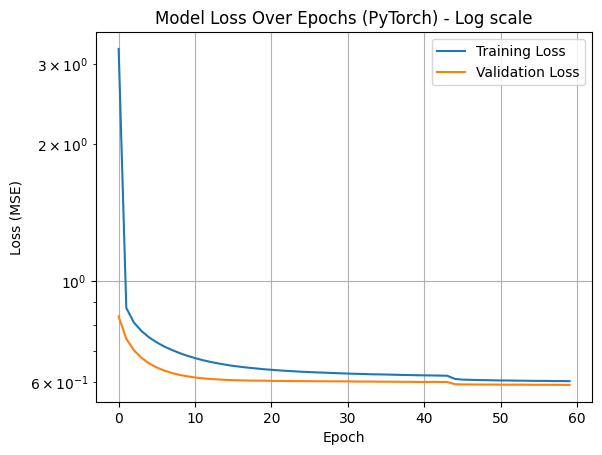

In [17]:
# Plotting the losses
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs (PyTorch) - Log scale')
plt.ylabel('Loss (MSE)')
plt.yscale("log")
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()

## Step 3.5: Visualization - model architecture

In [18]:
# Display Model Architecture
print(model)

# Calculate Trainable Parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

for name, param in model.named_parameters():
    print(f"{name:<20} {str(list(param.shape)):<20} {param.numel():,}")
print(f"\nTotal Trainable Parameters: {total_params:,}")    

RecommenderNet(
  (user_embedding): Embedding(200948, 64)
  (movie_embedding): Embedding(84432, 64)
  (user_dropout): Dropout(p=0.15, inplace=False)
  (movie_dropout): Dropout(p=0.15, inplace=False)
)
user_embedding.weight [200948, 64]         12,860,672
movie_embedding.weight [84432, 64]          5,403,648

Total Trainable Parameters: 18,264,320


### Note on Model size
**18 millions parameters** is small compared to a llama 70 billions parameters.
But it is very big compared to the 4 models I used in my app [Mix on Pix](https://apps.apple.com/us/app/mix-on-pix-text-on-photos/id633281586). 
They had 0.5 millions parameters each (but they run locally on an iPhone).

# Step 4: Similarity Search

## Step 4.1: Preparation

In [19]:
# Reload the best model weights
model.load_state_dict(torch.load(model_filename, weights_only=True))
model.eval()

# Extract Movie Embeddings (move to CPU and convert to numpy)
movie_embedding_matrix = model.movie_embedding.weight.detach().cpu().numpy()

# Prepare Dataframe for titles
df_movies = pd.read_csv(f'{movieslens_path}/movies.csv')
df_movies['movie_idx'] = df_movies['movieId'].map(movie_map)
df_movies = df_movies.dropna(subset=['movie_idx'])
df_movies['movie_idx'] = df_movies['movie_idx'].astype(int)
idx_to_title = df_movies.set_index('movie_idx')['title'].to_dict()

def find_similar_movies(movie_title, top_n=10):
    """
    Finds movies similar to a given movie using the learned embeddings.
    """
    try:
        movie_idx = df_movies[df_movies['title'] == movie_title]['movie_idx'].iloc[0]
        movie_vector = movie_embedding_matrix[movie_idx]
        sim_scores = cosine_similarity(movie_vector.reshape(1, -1), movie_embedding_matrix)
        sim_scores = list(enumerate(sim_scores[0]))
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
        
        top_similar_movies = [
            (idx_to_title.get(i, "Unknown"), score)
            for i, score in sim_scores[1:top_n + 1]
        ]
        
        print(f"Top {top_n} movies similar to '{movie_title}':")
        for title, score in top_similar_movies:
            print(f"  - {title} (Similarity: {score:.4f})")
    except IndexError:
        print(f"Movie '{movie_title}' not found.")

## Step 4.2: Test our trained model

In [20]:
# --- Let's test it! ---
find_similar_movies('Apocalypse Now (1979)')
print("-" * 30)
find_similar_movies('Arrival (2016)')
print("-" * 30)
find_similar_movies('Inception (2010)')
print("-" * 30)
find_similar_movies('My Life as a Dog (Mitt liv som hund) (1985)')
print("-" * 30)
find_similar_movies('Other Guys, The (2010)')
print("-" * 30)

Top 10 movies similar to 'Apocalypse Now (1979)':
  - Taxi Driver (1976) (Similarity: 0.9268)
  - Full Metal Jacket (1987) (Similarity: 0.9235)
  - Deer Hunter, The (1978) (Similarity: 0.9032)
  - Platoon (1986) (Similarity: 0.8955)
  - Raging Bull (1980) (Similarity: 0.8933)
  - Conversation, The (1974) (Similarity: 0.8737)
  - Once Upon a Time in America (1984) (Similarity: 0.8734)
  - Chinatown (1974) (Similarity: 0.8690)
  - Salvador (1986) (Similarity: 0.8671)
  - Clockwork Orange, A (1971) (Similarity: 0.8666)
------------------------------
Top 10 movies similar to 'Arrival (2016)':
  - Ex Machina (2015) (Similarity: 0.8673)
  - Interstellar (2014) (Similarity: 0.8609)
  - The Martian (2015) (Similarity: 0.8555)
  - Coherence (2013) (Similarity: 0.8537)
  - April Is the Cruellest Month (1983) (Similarity: 0.8531)
  - Murder on the Victorian Railway (2013) (Similarity: 0.8519)
  - My Love Came Back (1940) (Similarity: 0.8517)
  - Wind River (2017) (Similarity: 0.8466)
  - Moon (20

In [21]:
# --- More tests ---
find_similar_movies('Toy Story (1995)')
print("-" * 30)
find_similar_movies('Parenthood (1989)')
print("-" * 30)
find_similar_movies('Eyes Wide Shut (1999)')
print("-" * 30)
find_similar_movies('Thirteenth Floor, The (1999)')
print("-" * 30)
find_similar_movies('Little Miss Sunshine (2006)')
print("-" * 30)
find_similar_movies('Finding Nemo (2003)')
print("-" * 30)
find_similar_movies('Wild (2016)')
print("-" * 30)
find_similar_movies('Hidden Figures (2016)')
print("-" * 30)
find_similar_movies('Before Midnight (2013)')
print("-" * 30)
find_similar_movies('Begin Again (2013)')
print("-" * 30)

Top 10 movies similar to 'Toy Story (1995)':
  - Toy Story 2 (1999) (Similarity: 0.9748)
  - Toy Story 3 (2010) (Similarity: 0.9454)
  - Finding Nemo (2003) (Similarity: 0.9236)
  - Monsters, Inc. (2001) (Similarity: 0.9229)
  - Bug's Life, A (1998) (Similarity: 0.9215)
  - Incredibles, The (2004) (Similarity: 0.8996)
  - Up (2009) (Similarity: 0.8730)
  - Ratatouille (2007) (Similarity: 0.8422)
  - Toy Story 4 (2019) (Similarity: 0.8409)
  - Iron Giant, The (1999) (Similarity: 0.8394)
------------------------------
Top 10 movies similar to 'Parenthood (1989)':
  - Roxanne (1987) (Similarity: 0.8802)
  - Mr. Mom (1983) (Similarity: 0.8774)
  - No Way Out (1987) (Similarity: 0.8687)
  - Night Shift (1982) (Similarity: 0.8608)
  - When Harry Met Sally... (1989) (Similarity: 0.8543)
  - Witness (1985) (Similarity: 0.8478)
  - Dave (1993) (Similarity: 0.8457)
  - WarGames (1983) (Similarity: 0.8445)
  - Big (1988) (Similarity: 0.8442)
  - Win Win (2011) (Similarity: 0.8441)
---------------

## Step 5 - Create an ONNX model

In [22]:
# ==========================================
# ONNX Export (Oracle 23ai Ready)
# ==========================================
print("\nConverting model to ONNX...")

# 1. Load the best saved weights first
model.load_state_dict(torch.load(model_filename, weights_only=True))
model.eval() 

# 2. Create dummy inputs (required for PyTorch tracing)
# These define the shape/type, not the actual data.
dummy_user = torch.tensor([1], dtype=torch.long).to(device)
dummy_movie = torch.tensor([1], dtype=torch.long).to(device)

# 3. Define Names for Oracle Mapping
# These must match the names you expect to use in your SQL call
input_names = ["user_input", "movie_input"]
output_names = ["rating"]

# 4. Define Dynamic Axes
# This allows Oracle to pass batch sizes of 1 (single row) or N (batch processing)
dynamic_axes = {
    "user_input": {0: "batch_size"},
    "movie_input": {0: "batch_size"},
    "rating": {0: "batch_size"}
}

# 5. Export to ONNX
torch.onnx.export(
    model,
    (dummy_user, dummy_movie),
    onnx_filename,
    export_params=True,
    opset_version=15,          # Opset 15 works for Oracle 23ai
    do_constant_folding=True,
    input_names=input_names,
    output_names=output_names,
    dynamic_axes=dynamic_axes
)

print(f"SUCCESS: PyTorch model converted and saved to: {onnx_filename}")
print(f"Input names: {input_names}")
print(f"Output names: {output_names}")



Converting model to ONNX...
SUCCESS: PyTorch model converted and saved to: ../saved_models/cf_recommender.onnx
Input names: ['user_input', 'movie_input']
Output names: ['rating']
